# Crop Recommendation Dataset
## Exploratory Data Analysis (EDA) & Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")


Dataset overview (head(), info(), describe())

Missing value check

Duplicate check

In [5]:

data = pd.read_csv('/content/Crop_Recommendation.csv')
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [6]:

data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# EDA (Exploratory Data Analysis)

 Histogram distribution

Boxplot (outlier detection)

Correlation heatmap

Crop distribution (target variable analysis)

In [7]:
data.isnull().sum()

,0
Nitrogen,0
Phosphorus,0
Potassium,0
Temperature,0
Humidity,0
pH_Value,0
Rainfall,0
Crop,0


In [8]:
data.duplicated().sum()

np.int64(0)

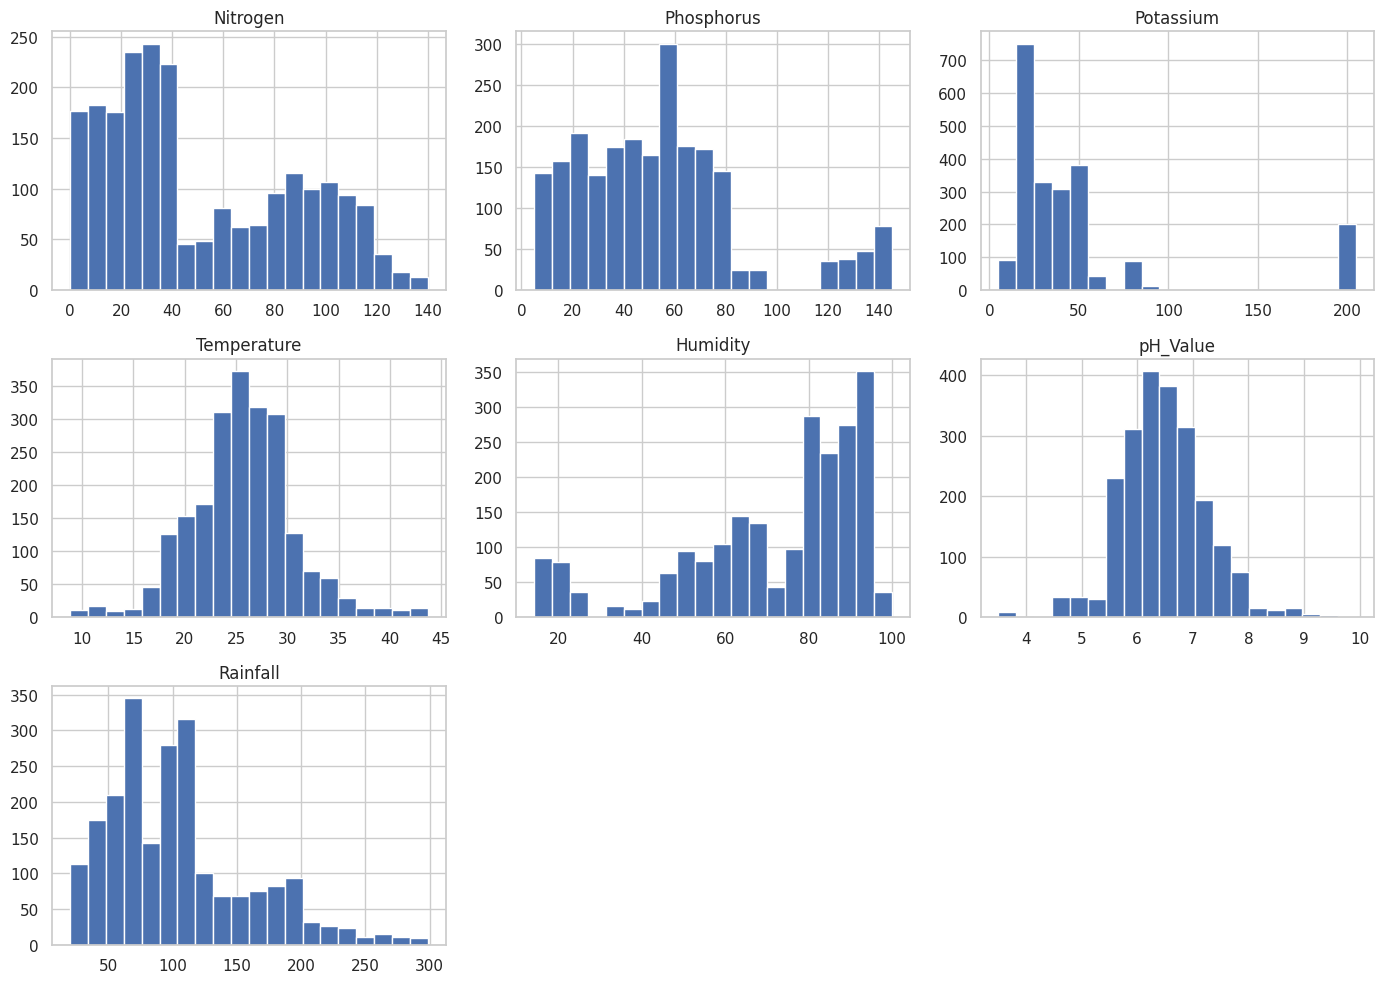

In [9]:

data.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

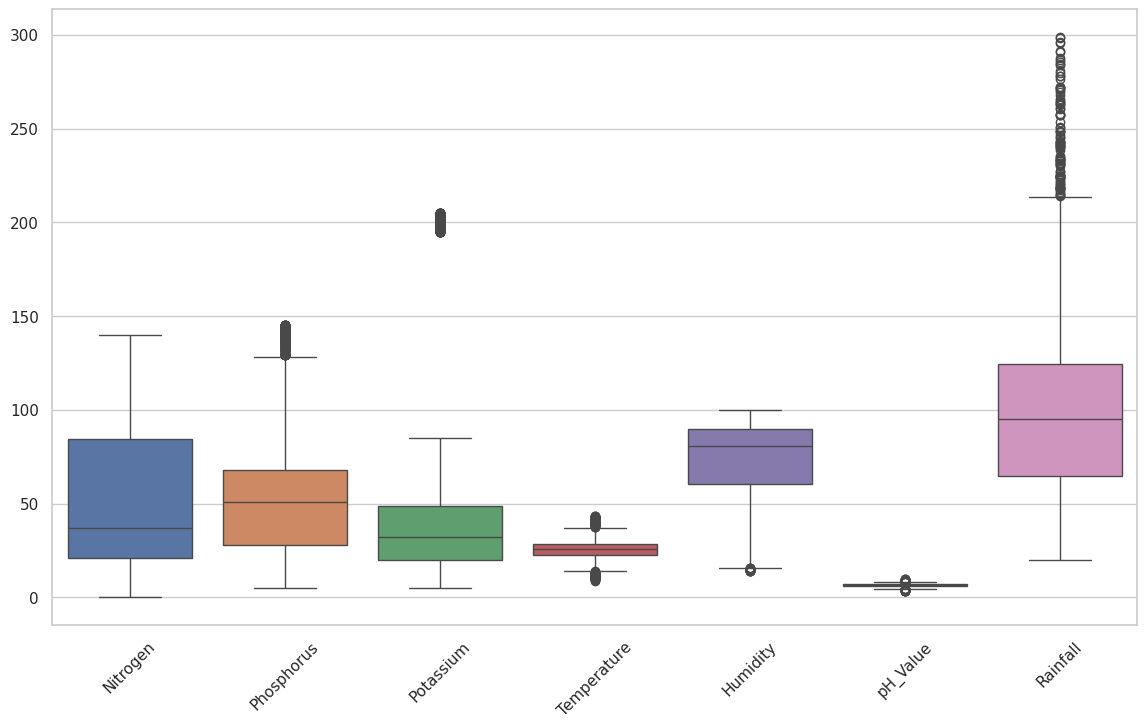

In [10]:

plt.figure(figsize=(14,8))
sns.boxplot(data=data.drop('Crop', axis=1))
plt.xticks(rotation=45)
plt.show()

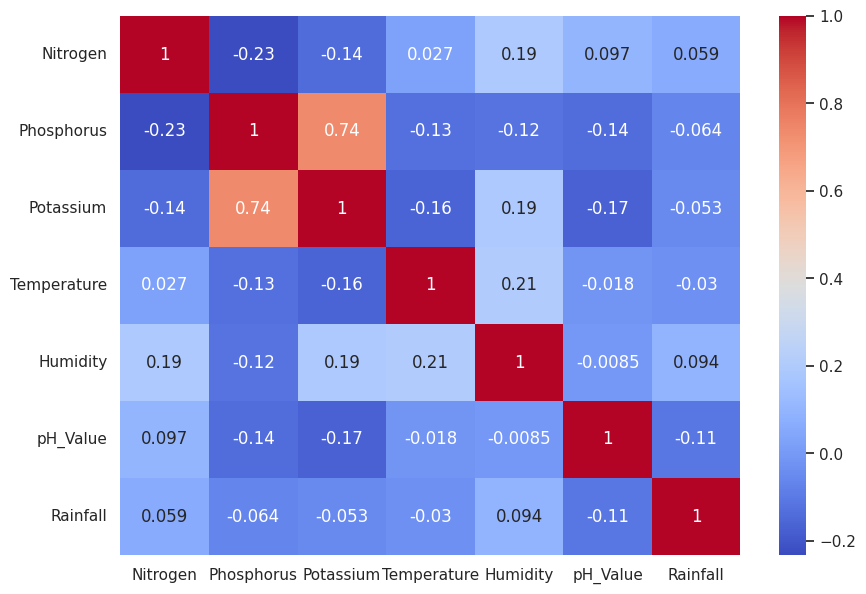

In [11]:

plt.figure(figsize=(10,7))
corr = data.drop('Crop', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Data Preprocessing
In this part i am doing

Label Encoding (convert crop names → numbers)

Feature / Target split

Standardization (StandardScaler)

Train Test Split (80% – 20%)

Saves processed dataset files

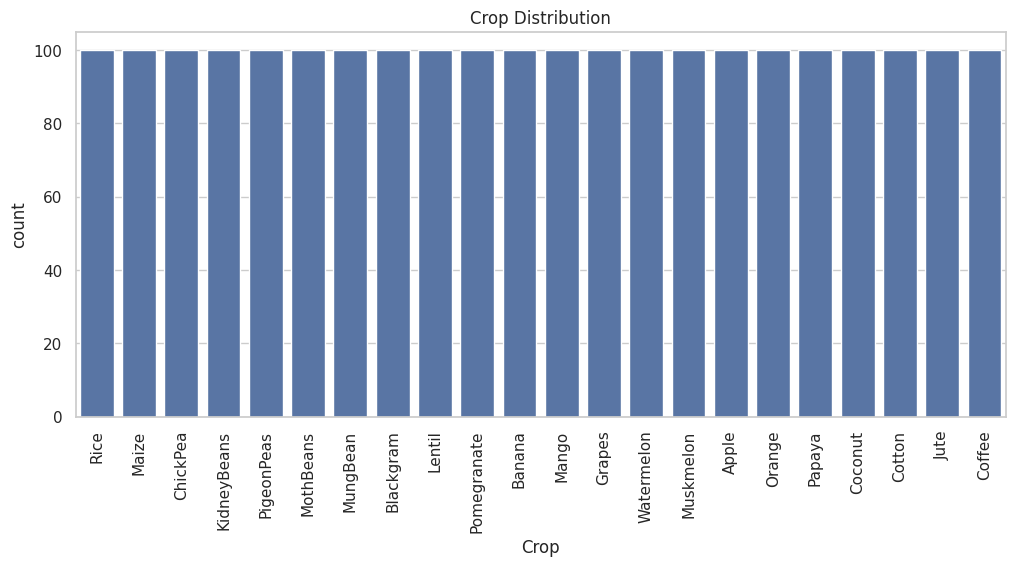

In [12]:

plt.figure(figsize=(12,5))
sns.countplot(x='Crop', data=data)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

In [15]:

le = LabelEncoder()
data['Crop_Label'] = le.fit_transform(data['Crop'])
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Crop_Label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice,20


In [16]:

X = data.drop(['Crop','Crop_Label'], axis=1)
y = data['Crop_Label']

In [17]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1760, 7)
Testing Shape: (440, 7)


In [21]:

X_train.to_csv('X_train_processed.csv', index=False)
X_test.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Files Saved Successfully!")

Files Saved Successfully!
